# Network Traffic GAN for DDoS Data

In [1]:
import os
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: cuda


## Settings

In [6]:
file_path = "Wednesday-workingHours.pcap_ISCX.csv"

batch_size = 128
latent_dim = 64
num_epochs = 100
generator_lr = 0.0002
discriminator_lr = 0.00015
beta1 = 0.5
beta2 = 0.999
real_label_value = 0.9
fake_label_value = 0.0
max_samples = 20000

## Load the Dataset

In [7]:
df = pd.read_csv(file_path)
print("Original dataset shape:", df.shape)

df.columns = df.columns.str.strip()

if "Label" not in df.columns:
    print("Error: Label column not found!")

print("Number of columns:", len(df.columns))
print("First 10 columns:", df.columns[:10].tolist())

Original dataset shape: (692703, 79)
Number of columns: 79
First 10 columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']


## Check the Labels

Class distribution before filtering:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


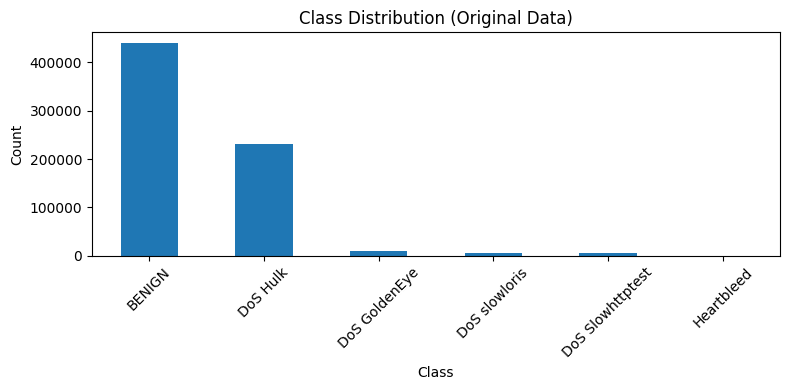

In [8]:
label_counts = df["Label"].value_counts()
print("Class distribution before filtering:")
print(label_counts)

plt.figure(figsize=(8, 4))
label_counts.plot(kind="bar")
plt.title("Class Distribution (Original Data)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Keep Only the Classes We Want

Filtered dataset shape: (692692, 79)
Class distribution after filtering:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Name: count, dtype: int64


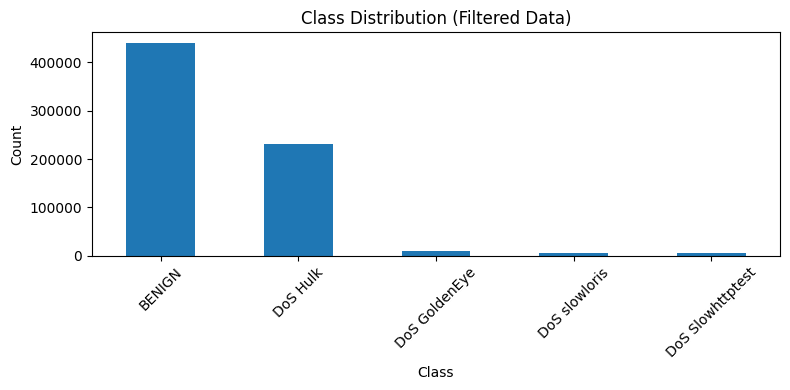

In [9]:
selected_classes = [
    "BENIGN",
    "DoS Hulk",
    "DoS GoldenEye",
    "DoS slowloris",
    "DoS Slowhttptest"
]

df_filtered = df[df["Label"].isin(selected_classes)]
df_filtered = df_filtered.copy()
print("Filtered dataset shape:", df_filtered.shape)

filtered_counts = df_filtered["Label"].value_counts()
print("Class distribution after filtering:")
print(filtered_counts)

plt.figure(figsize=(8, 4))
filtered_counts.plot(kind="bar")
plt.title("Class Distribution (Filtered Data)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Clean the Features

In [10]:
X = df_filtered.drop(columns=["Label"])
X = X.copy()

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna(axis=0)

labels_filtered = df_filtered.loc[X.index, "Label"]
labels_filtered = labels_filtered.reset_index(drop=True)
X = X.reset_index(drop=True)

print("Feature matrix shape after cleaning:", X.shape)

Feature matrix shape after cleaning: (691395, 78)


## Scale the Data

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

if len(X_scaled) > max_samples:
    random_indexes = np.random.choice(len(X_scaled), max_samples, replace=False)
    X_scaled = X_scaled[random_indexes]
    labels_filtered = labels_filtered.iloc[random_indexes]
    labels_filtered = labels_filtered.reset_index(drop=True)

print("Final training shape:", X_scaled.shape)

Final training shape: (20000, 78)


## Make a PyTorch DataLoader

In [12]:
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
train_dataset = TensorDataset(X_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

feature_dim = X_tensor.shape[1]
print("Number of features used:", feature_dim)

Number of features used: 78


## The Generator

In [13]:
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, output_dim)
        )

    def forward(self, z):
        output = self.model(z)
        return output

## The Discriminator

In [14]:
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        output = self.model(x)
        return output

## Make the Models, Loss and Optimizers

In [15]:
generator = Generator(latent_dim, feature_dim)
generator = generator.to(device)

discriminator = Discriminator(feature_dim)
discriminator = discriminator.to(device)

loss_function = nn.BCELoss()

generator_optimizer = torch.optim.Adam(generator.parameters(), lr=generator_lr, betas=(beta1, beta2))
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=discriminator_lr, betas=(beta1, beta2))

print(generator)
print(discriminator)

Generator(
  (model): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=128, out_features=256, bias=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=256, out_features=78, bias=True)
  )
)
Discriminator(
  (model): Sequential(
    (0): Linear(in_features=78, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.25, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


## Training Loop

In [16]:
generator_losses = []
discriminator_losses = []

for epoch in range(num_epochs):

    total_g_loss = 0.0
    total_d_loss = 0.0
    num_batches = 0

    for batch_data in train_loader:
        real_batch = batch_data[0]
        real_batch = real_batch.to(device)

        current_batch_size = real_batch.size(0)

        real_targets = torch.full((current_batch_size, 1), real_label_value, device=device)
        fake_targets = torch.full((current_batch_size, 1), fake_label_value, device=device)

        discriminator_optimizer.zero_grad()

        real_preds = discriminator(real_batch)
        loss_real = loss_function(real_preds, real_targets)

        noise = torch.randn(current_batch_size, latent_dim, device=device)
        fake_batch = generator(noise)

        fake_preds = discriminator(fake_batch.detach())
        loss_fake = loss_function(fake_preds, fake_targets)

        d_loss = loss_real + loss_fake
        d_loss.backward()
        discriminator_optimizer.step()

        generator_optimizer.zero_grad()

        noise = torch.randn(current_batch_size, latent_dim, device=device)
        generated_batch = generator(noise)
        gen_preds = discriminator(generated_batch)

        g_loss = loss_function(gen_preds, real_targets)
        g_loss.backward()
        generator_optimizer.step()

        total_d_loss = total_d_loss + d_loss.item()
        total_g_loss = total_g_loss + g_loss.item()
        num_batches = num_batches + 1

    average_d_loss = total_d_loss / num_batches
    average_g_loss = total_g_loss / num_batches

    discriminator_losses.append(average_d_loss)
    generator_losses.append(average_g_loss)

    print_this_epoch = False
    if (epoch + 1) % 10 == 0:
        print_this_epoch = True
    if epoch == 0:
        print_this_epoch = True

    if print_this_epoch == True:
        print("Epoch", epoch + 1, "/", num_epochs, "| D Loss:", round(average_d_loss, 4), "| G Loss:", round(average_g_loss, 4))

Epoch 1 / 100 | D Loss: 1.3417 | G Loss: 0.7251
Epoch 10 / 100 | D Loss: 1.12 | G Loss: 1.1061
Epoch 20 / 100 | D Loss: 1.0527 | G Loss: 1.2493
Epoch 30 / 100 | D Loss: 1.0284 | G Loss: 1.3145
Epoch 40 / 100 | D Loss: 1.0124 | G Loss: 1.3282
Epoch 50 / 100 | D Loss: 1.006 | G Loss: 1.3385
Epoch 60 / 100 | D Loss: 0.9989 | G Loss: 1.3574
Epoch 70 / 100 | D Loss: 0.9896 | G Loss: 1.3652
Epoch 80 / 100 | D Loss: 0.9704 | G Loss: 1.4042
Epoch 90 / 100 | D Loss: 0.9522 | G Loss: 1.4307
Epoch 100 / 100 | D Loss: 0.9541 | G Loss: 1.4306


## Plot the Training Losses

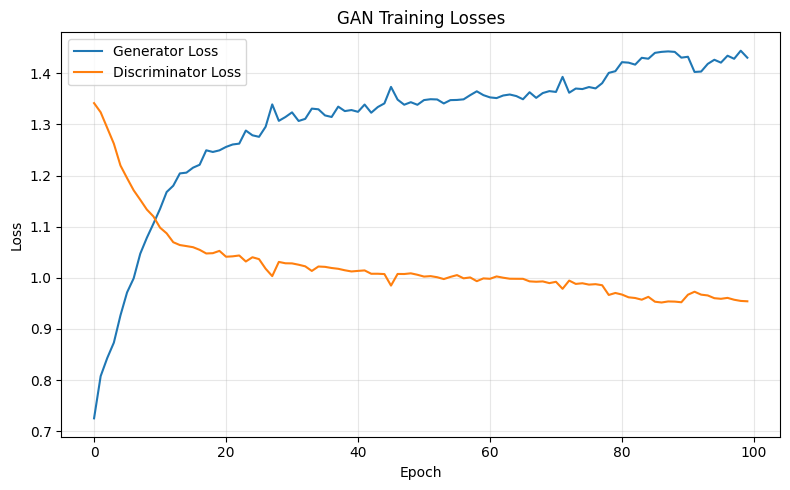

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(generator_losses, label="Generator Loss")
plt.plot(discriminator_losses, label="Discriminator Loss")
plt.title("GAN Training Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Generate Synthetic Samples

In [18]:
generator.eval()

num_samples = 2000
if num_samples > len(X_scaled):
    num_samples = len(X_scaled)

with torch.no_grad():
    noise = torch.randn(num_samples, latent_dim, device=device)
    generated_scaled = generator(noise)
    generated_scaled = generated_scaled.cpu()
    generated_scaled = generated_scaled.numpy()

generated_original = scaler.inverse_transform(generated_scaled)
generated_df = pd.DataFrame(generated_original, columns=X.columns)

print("Generated synthetic sample shape:", generated_df.shape)
print("First 5 generated rows:")
print(generated_df.head())

Generated synthetic sample shape: (2000, 78)
First 5 generated rows:
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0        -19.464693  -5.797958e+05           8.121076                0.583054   
1         -9.897799   6.169942e+05           4.882100               -0.947244   
2       1664.011108  -2.875154e+06          41.689671               17.586628   
3        523.686646   1.658642e+07          24.811563              -47.374752   
4        237.073883   6.508482e+05          -5.599411               -6.398487   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                   144.278000                  4493.997070   
1                    50.534351                  9181.823242   
2                  3352.544189                 75962.796875   
3                  1266.329590                -37025.488281   
4                   135.085220                 -1557.409180   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Lengt

## PCA: Real vs Generated

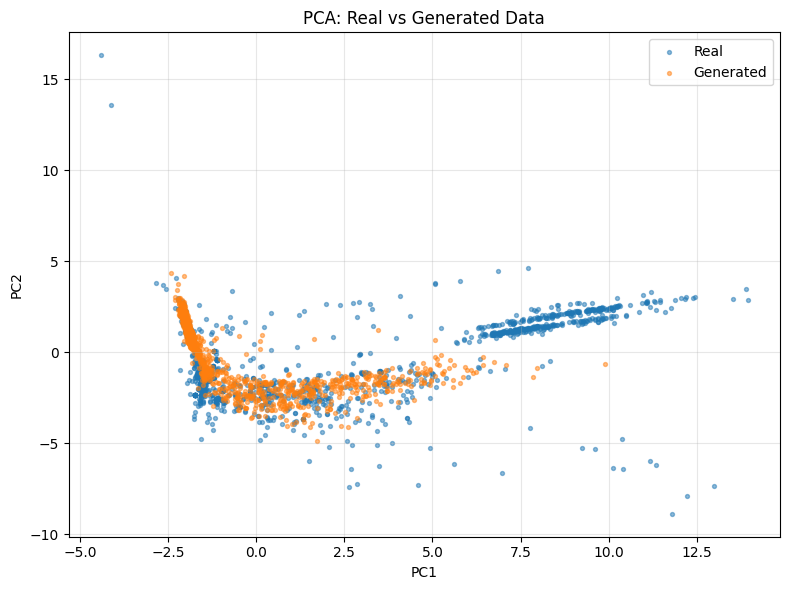

In [19]:
n = 2000
if n > len(X_scaled):
    n = len(X_scaled)
if n > len(generated_scaled):
    n = len(generated_scaled)

real_subset = X_scaled[:n]
fake_subset = generated_scaled[:n]

combined = np.vstack([real_subset, fake_subset])

pca = PCA(n_components=2, random_state=42)
combined_pca = pca.fit_transform(combined)

real_pca = combined_pca[:n]
fake_pca = combined_pca[n:]

plt.figure(figsize=(8, 6))
plt.scatter(real_pca[:, 0], real_pca[:, 1], s=8, alpha=0.5, label="Real")
plt.scatter(fake_pca[:, 0], fake_pca[:, 1], s=8, alpha=0.5, label="Generated")
plt.title("PCA: Real vs Generated Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Numeric Comparison of Real vs Fake

In [20]:
real_means = X_scaled.mean(axis=0)
fake_means = generated_scaled.mean(axis=0)

real_stds = X_scaled.std(axis=0)
fake_stds = generated_scaled.std(axis=0)

mean_differences = np.abs(real_means - fake_means)
std_differences = np.abs(real_stds - fake_stds)

average_mean_diff = mean_differences.mean()
average_std_diff = std_differences.mean()

print("Average absolute difference in feature means:", round(average_mean_diff, 4))
print("Average absolute difference in feature stds :", round(average_std_diff, 4))

Average absolute difference in feature means: 0.2024
Average absolute difference in feature stds : 0.5086
